<a href="https://colab.research.google.com/github/jonathancagua/audio/blob/main/audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Este conjunto de datos recopila cantos de cinco especies de aves (Cucarachero de Bewick, Cardenal Norteño, Robin Americano, Gorrión Melódico y Cenzontle Norteño) con el objetivo de entrenar modelos de identificación a partir de grabaciones de 3 segundos. Los audios, extraídos de la plataforma xeno-canto, están estandarizados en formato wav (22050 Hz, mono) y se incluyen en un archivo CSV con metadatos asociados. Puede explorar el conjunto de datos completo en [Kaggle](
https://www.kaggle.com/datasets/vinayshanbhag/bird-song-data-set)

In [1]:
import pandas as pd
import numpy as np
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import librosa.display
from sklearn.model_selection import train_test_split
import keras
from keras import Model, Input
from keras.layers import Conv1D, Flatten, Dense, Dropout, SpatialDropout1D, GlobalAveragePooling1D
from keras.optimizers import Adam
from keras.optimizers.schedules import ExponentialDecay
from keras.losses import SparseCategoricalCrossentropy
from keras.metrics import SparseCategoricalAccuracy
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, roc_auc_score
from keras.callbacks import TensorBoard, ModelCheckpoint
import seaborn as sns

In [2]:
!pip install kaggle

In [3]:
!kaggle datasets download -d vinayshanbhag/bird-song-data-set --unzip -p ./bird-data



Dataset URL: https://www.kaggle.com/datasets/vinayshanbhag/bird-song-data-set
License(s): other
100% 2.09G/2.09G [00:53<00:00, 41.7MB/s]



In [4]:
import os

DATA_DIR = "/content/bird-data"
metadata = pd.read_csv(f"{DATA_DIR}/bird_songs_metadata.csv")

label_dict = {
    'bewickii': 0, 'polyglottos': 1, 'migratorius': 2,
    'melodia': 3, 'cardinalis': 4
}
bird_labels = metadata['species'].map(label_dict).values

bird_filepaths = (DATA_DIR + "/wavfiles/" + metadata['filename']).values

bird_filepaths_train, bird_filepaths_val, bird_labels_train, bird_labels_val = train_test_split(
    bird_filepaths, bird_labels, test_size=0.10, random_state=2419
)


In [5]:
def load_audio(path):
    path_en_bytes = path.numpy()

    path_string = path_en_bytes.decode('utf-8')

    y, _ = librosa.load(path_string, sr=22050)
    return y.astype(np.float32)



def map_function(path_tensor, label):
    y = tf.py_function(load_audio, [path_tensor], tf.float32)
    y.set_shape([None])

    # 1. STFT
    stft = tf.signal.stft(y, frame_length=512, frame_step=64)
    spectrogram = tf.abs(stft)

    # 2. dB con logaritmo base 10 (Escala estándar)
    # tf.math.log(x) / tf.math.log(10.0) para emular log10
    log10_spec = tf.math.log(spectrogram + 1e-6) / tf.math.log(10.0)
    spectrogram_db = 20.0 * log10_spec - 20.0 * (tf.math.log(100.0) / tf.math.log(10.0))

    # 3. Normalización Min-Max
    spectrogram_norm = (spectrogram_db + 80.0) / 80.0
    spectrogram_norm = tf.clip_by_value(spectrogram_norm, 0.0, 1.0)

    return spectrogram_norm, label





In [6]:
def make_dataset(labels, filepaths, shuffle=False, batch_size=32):
    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(filepaths))

    dataset = dataset.map(map_function, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.padded_batch(batch_size, drop_remainder=True)

    return dataset.prefetch(tf.data.AUTOTUNE)


In [7]:
dataset_train = make_dataset(bird_labels_train, bird_filepaths_train, shuffle=True)
dataset_val = make_dataset(bird_labels_val, bird_filepaths_val, shuffle=False)


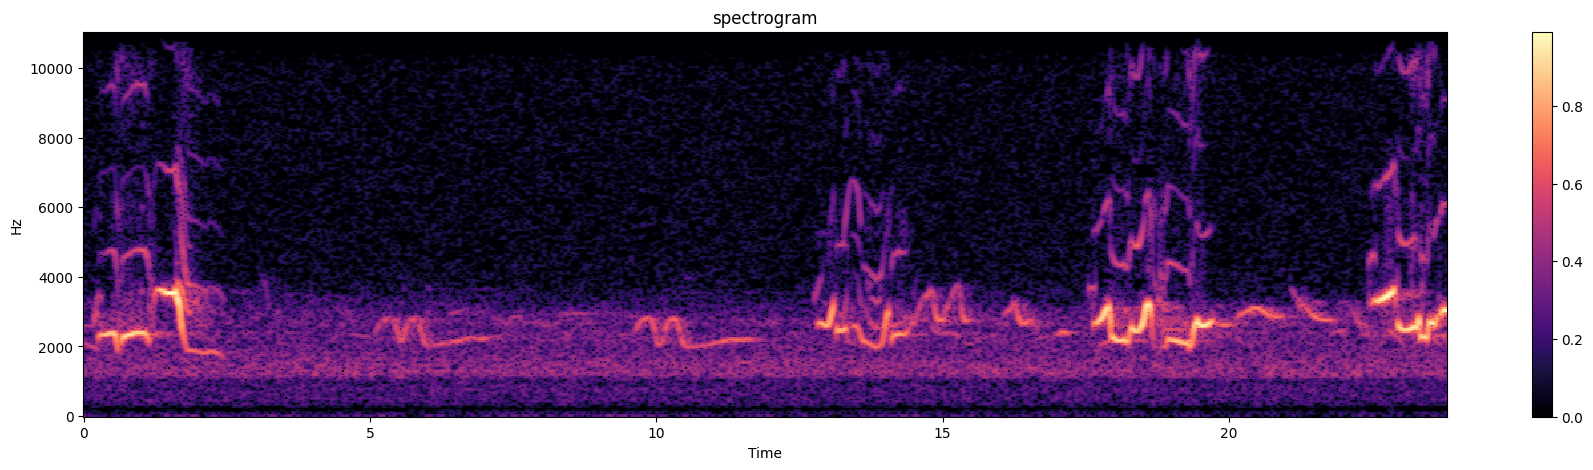

In [8]:
for spectrograms,labels in dataset_train:
    plt.figure(figsize=(22,5))
    librosa.display.specshow(spectrograms[0].numpy().T,y_axis='linear', x_axis='time', cmap = 'magma')
    plt.colorbar()
    plt.title('spectrogram')
    plt.show()
    break

In [9]:
from keras import Model, Input
from keras.layers import Conv1D, Flatten, Dense, Dropout, SpatialDropout1D, GlobalAveragePooling1D, BatchNormalization

def create_model():
    inputs = Input(shape=(None, 257), name='0_Input_shape')

    # Bloque 1
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='1_Conv1D')(inputs)
    x = BatchNormalization()(x) # Agregado: Estabiliza el entrenamiento
    x = SpatialDropout1D(0.17, name='2_SpatialDropout1D')(x)

    # Bloque 2
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='3_Conv1d')(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.17, name='4_SpatialDropout1D')(x)

    # Bloque 3
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='5_Conv1d')(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.17, name='6_SpatialDropout1D')(x)

    # Bloque 4
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='7_Conv1d')(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.17, name='8_SpatialDropout1D')(x)

    # Reducción y Clasificación
    x = GlobalAveragePooling1D(name='9_Global_avg_pooling')(x)
    x = Dense(512, activation='relu', name='10_Dense')(x)
    x = Dropout(0.5, name='11_Dropout')(x)

    # activation='softmax'
    outputs = Dense(5, activation='softmax', name='12_Output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Bird_audio_classification_model')
    return model


In [10]:
# Instanciar y compilar
model = create_model()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "Bird_audio_classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 0_Input_shape (InputLayer)      │ (None, None, 257)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1_Conv1D (Conv1D)               │ (None, None, 128)      │       263,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, None, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2_SpatialDropout1D              │ (None, None, 128)      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3_Conv1d (Conv1D)               │ (None, None, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, None, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4_SpatialDropout1D              │ (None, None, 128)      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5_Conv1d (Conv1D)               │ (None, None, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, None, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 6_SpatialDropout1D              │ (None, None, 128)      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 7_Conv1d (Conv1D)               │ (None, None, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, None, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 8_SpatialDropout1D              │ (None, None, 128)      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 9_Global_avg_pooling            │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 10_Dense (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 11_Dropout (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 12_Output (Dense)               │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 727,557 (2.78 MB)

 Trainable params: 726,533 (2.77 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [12]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
import os

logdir = 'tb_logs/modelo_final'

checkpoint = ModelCheckpoint(
    filepath='mejor_modelo_pajaros.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

tb_callback = TensorBoard(log_dir=logdir)

history = model.fit(
    dataset_train,
    validation_data=dataset_val,
    epochs=50,
    callbacks=[checkpoint, early_stop, tb_callback]
)


Epoch 1/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.4249 - loss: 1.3220
Epoch 1: val_accuracy improved from None to 0.37109, saving model to mejor_modelo_pajaros.keras

Epoch 1: finished saving model to mejor_modelo_pajaros.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 58s 240ms/step - accuracy: 0.4751 - loss: 1.2005 - val_accuracy: 0.3711 - val_loss: 3.6880
Epoch 2/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.5682 - loss: 1.0170
Epoch 2: val_accuracy improved from 0.37109 to 0.55469, saving model to mejor_modelo_pajaros.keras

Epoch 2: finished saving model to mejor_modelo_pajaros.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 36s 235ms/step - accuracy: 0.5917 - loss: 0.9786 - val_accuracy: 0.5547 - val_loss: 1.0800
Epoch 3/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.6061 - loss: 0.9400
Epoch 3: val_accuracy improved from 0.55469 to 0.57812, saving model to mejor_modelo_pajaros.keras

Epoch 3: finished saving model to mejor_modelo_pajaros.keras
152/152 ━━━━━━━━

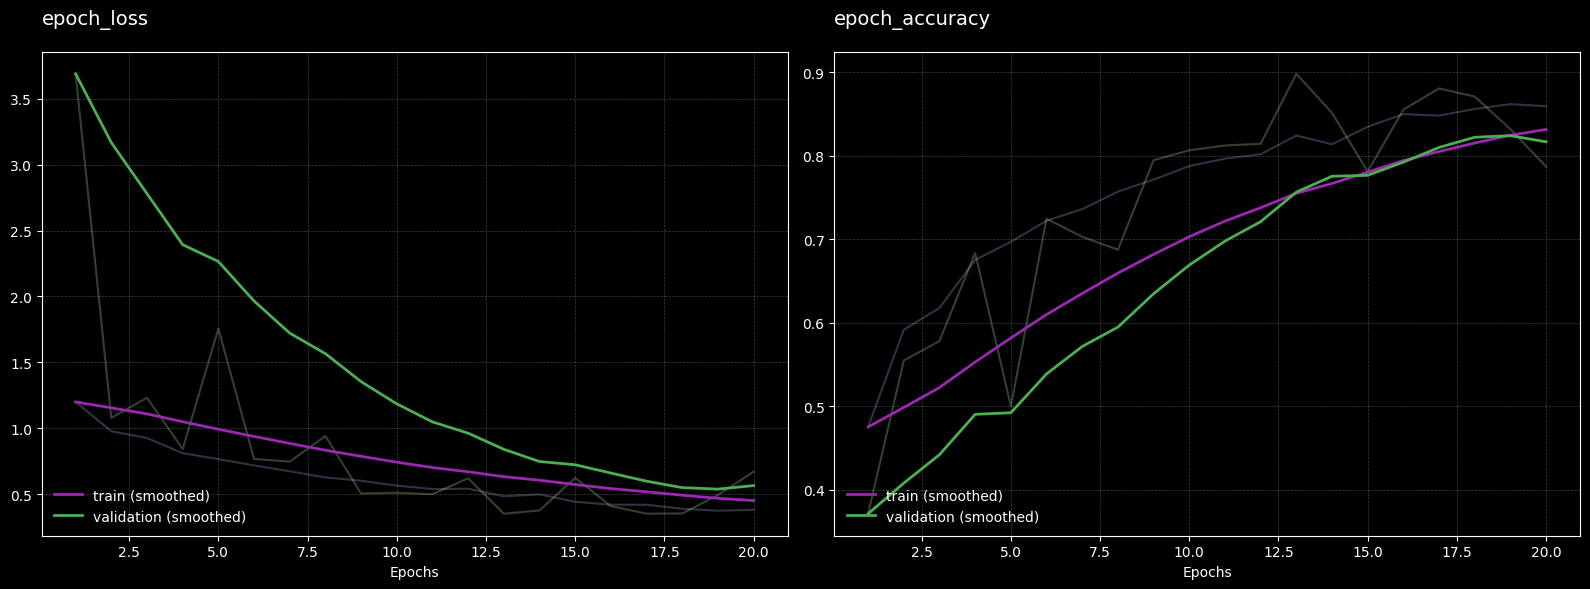

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tensorboard_style(history):
    plt.style.use('dark_background')

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    def smooth_curve(points, factor=0.8):
        smoothed_points = []
        for point in points:
            if smoothed_points:
                previous = smoothed_points[-1]
                smoothed_points.append(previous * factor + point * (1 - factor))
            else:
                smoothed_points.append(point)
        return smoothed_points

    plt.figure(figsize=(16, 6))

    # --- Gráfico de Pérdida (Loss) ---
    plt.subplot(1, 2, 1)
    # Líneas tenues (datos reales)
    plt.plot(epochs, loss, color='#b39ddb', alpha=0.3)
    plt.plot(epochs, val_loss, color='#a5d6a7', alpha=0.3)
    # Líneas gruesas (suavizadas)
    plt.plot(epochs, smooth_curve(loss), color='#9c27b0', label='train (smoothed)', linewidth=2)
    plt.plot(epochs, smooth_curve(val_loss), color='#4caf50', label='validation (smoothed)', linewidth=2)

    plt.title('epoch_loss', loc='left', fontsize=14, pad=20)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(loc='lower left', frameon=False)
    plt.xlabel('Epochs')

    # --- Gráfico de Precisión (Accuracy) ---
    plt.subplot(1, 2, 2)
    # Líneas tenues
    plt.plot(epochs, acc, color='#b39ddb', alpha=0.3)
    plt.plot(epochs, val_acc, color='#a5d6a7', alpha=0.3)
    # Líneas gruesas
    plt.plot(epochs, smooth_curve(acc), color='#9c27b0', label='train (smoothed)', linewidth=2)
    plt.plot(epochs, smooth_curve(val_acc), color='#4caf50', label='validation (smoothed)', linewidth=2)

    plt.title('epoch_accuracy', loc='left', fontsize=14, pad=20)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(loc='lower left', frameon=False)
    plt.xlabel('Epochs')

    plt.tight_layout()
    plt.show()

# Ejecutar después del entrenamiento
plot_tensorboard_style(history)



In [14]:
model_eval = tf.keras.models.load_model('mejor_modelo_pajaros.keras')

results = model_eval.evaluate(dataset_val, return_dict=True)

print("\n--- Resultados de la Evaluación ---")
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.8984 - loss: 0.3536

--- Resultados de la Evaluación ---
accuracy: 0.8984
loss: 0.3536


In [15]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

bird_names = ['bewickii', 'polyglottos', 'migratorius', 'melodia', 'cardinalis']

print("Generando predicciones...")
y_logits = model_eval.predict(dataset_val)

y_pred = tf.argmax(y_logits, axis=1).numpy()

y_true_list = []
for _, labels in dataset_val:
    y_true_list.extend(labels.numpy())
y_true = np.array(y_true_list)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_true, y_pred, target_names=bird_names))



Generando predicciones...
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

    bewickii       0.88      0.86      0.87        86
 polyglottos       0.98      0.91      0.94       112
 migratorius       0.93      0.86      0.89        88
     melodia       0.86      0.91      0.89       128
  cardinalis       0.86      0.93      0.89        98

    accuracy                           0.90       512
   macro avg       0.90      0.90      0.90       512
weighted avg       0.90      0.90      0.90       512



In [16]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

print("Calculando predicciones...")
y_logits = model_eval.predict(dataset_val)

y_prob = tf.nn.softmax(y_logits, axis=1).numpy()

y_pred = np.argmax(y_logits, axis=1)

y_true_list = []
for _, labels in dataset_val:
    y_true_list.extend(labels.numpy())
y_true = np.array(y_true_list)

f1 = f1_score(y_true, y_pred, average='macro')
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
auc = roc_auc_score(y_true, y_prob, average='macro', multi_class='ovo')

# Imprimir resultados
print("-" * 30)
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC ROC:   {auc:.4f}")
print("-" * 30)



Calculando predicciones...
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step
------------------------------
F1 Score:  0.8975
Precision: 0.9015
Recall:    0.8955
AUC ROC:   0.9850
------------------------------


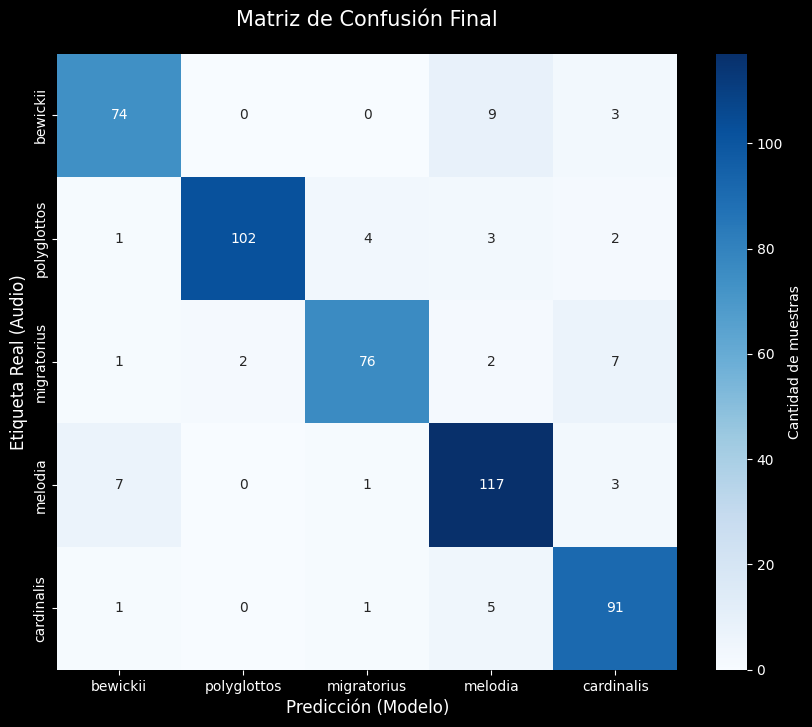

In [17]:
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('dark_background')

confusion_mtx = tf.math.confusion_matrix(y_true, y_pred).numpy()

bird_names = ['bewickii', 'polyglottos', 'migratorius', 'melodia', 'cardinalis']

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=bird_names,
            yticklabels=bird_names,
            annot=True,
            fmt='g',
            cmap='Blues', # O 'magma' si quieres el estilo de antes
            cbar_kws={'label': 'Cantidad de muestras'})

plt.title('Matriz de Confusión Final', fontsize=15, pad=20)
plt.xlabel('Predicción (Modelo)', fontsize=12)
plt.ylabel('Etiqueta Real (Audio)', fontsize=12)
plt.show()


In [18]:
!pip -q install -U tf2onnx onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 81.5 MB/s eta 0:00:00


In [20]:
import tensorflow as tf
import tf2onnx
import os

# 1. Selección robusta del modelo
model_to_export = None
if 'model_eval' in locals():
    model_to_export = model_eval
elif 'model' in locals():
    model_to_export = model
else:
    raise NameError("No se encontró 'model_eval' ni 'model'. Carga el modelo primero.")

# 2. Obtener dimensiones reales del dataset de validación
try:
    sample_x, _ = next(iter(dataset_val.take(1)))
    # Forzamos batch size 1 para compatibilidad RKNN/estática
    batch_size = 1
    time_steps = int(sample_x.shape[1])
    freq_bins = int(sample_x.shape[2])
    input_shape = (batch_size, time_steps, freq_bins)
except Exception as e:
    print(f"Error al obtener dimensiones del dataset: {e}")
    # Fallback manual si el dataset falla
    input_shape = (1, 128, 128)

# 3. Definición de la firma de entrada
# Usar un nombre simple como 'input' ayuda mucho en la conversión posterior a RKNN
spec = (tf.TensorSpec(input_shape, tf.float32, name='input'),)

# 4. Conversión a ONNX
onnx_path = 'bird_model.onnx'

print(f"Exportando modelo con input shape: {input_shape}...")

model_proto, _ = tf2onnx.convert.from_keras(
    model_to_export,
    input_signature=spec,
    opset=13,  # <--- Cambia esto
    output_path=onnx_path
)


if os.path.exists(onnx_path):
    print(f'\n ÉXITO: Modelo guardado en {onnx_path}')
    print(f'Input node: "input" | Shape: {input_shape}')


Exportando modelo con input shape: (1, 1026, 257)...

 ÉXITO: Modelo guardado en bird_model.onnx
Input node: "input" | Shape: (1, 1026, 257)
